# SciDCC Fine-tuning: Full FT vs LoRA

Model: `P0L3/SciClimateBERT` (RoBERTa arhitektura)  
Input: `title_summary`
Task: Klasifikacija u 20 klasa  
Target: pobiti baseline macro F1 = 53.75 (Mishra & Mittal, 2021)

Notebook radi dva eksperimenta sekvencijalno:
1. Full fine-tuning — sve tezine se azuriraju
2. LoRA (PEFT) — treniramo samo low-rank adaptere, enkoder zamrznut

Evaluacija na kraju svake varijante na test setu.

## 1. Setup

In [21]:
import json
import numpy as np
import torch
from pathlib import Path
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate

SEED = 42
torch.manual_seed(SEED)

PROCESSED_DIR  = Path('..') / 'data' / 'processed'
MODELS_DIR     = Path('..') / 'models'
MODELS_DIR.mkdir(exist_ok=True, parents=True)

MODEL_NAME = 'P0L3/SciClimateBERT'
INPUT_KEY  = 'hf_body'  # mijenja se u hf_body ili hf_title_summary

print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

CUDA: True
GPU:  NVIDIA GeForce RTX 3050
VRAM: 8.6 GB


In [22]:
# label mapping
with open(PROCESSED_DIR / 'label_map.json', 'r') as f:
    label_map = json.load(f)
label2id = label_map['label2id']
id2label = {int(k): v for k, v in label_map['id2label'].items()}
NUM_LABELS = len(label2id)
print(f'Broj klasa: {NUM_LABELS}')

# class weights za loss
with open(PROCESSED_DIR / 'class_weights.json', 'r') as f:
    cw = json.load(f)
class_weights = torch.tensor(cw['weights'], dtype=torch.float32)
print(f'Class weights min/max: {class_weights.min():.3f} / {class_weights.max():.3f}')

# dataset
ds = load_from_disk(str(PROCESSED_DIR / INPUT_KEY))
print(ds)

Broj klasa: 20
Class weights min/max: 0.587 / 26.910
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 8073
    })
    val: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1730
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1731
    })
})


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator  = DataCollatorWithPadding(tokenizer=tokenizer)

## 2. Metrike i custom Trainer

Primarna metrika je macro F1. Custom Trainer override-a `compute_loss` da koristi class-weighted CrossEntropyLoss.

In [23]:
metric_f1  = evaluate.load('f1')
metric_acc = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    macro_f1  = metric_f1.compute(predictions=preds, references=labels, average='macro')['f1']
    weighted_f1 = metric_f1.compute(predictions=preds, references=labels, average='weighted')['f1']
    acc = metric_acc.compute(predictions=preds, references=labels)['accuracy']
    return {
        'macro_f1':    round(macro_f1, 4),
        'weighted_f1': round(weighted_f1, 4),
        'accuracy':    round(acc, 4),
    }

In [24]:
class WeightedTrainer(Trainer):
    """Trainer s class-weighted CrossEntropyLoss za handling imbalancea."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

## 3. Full fine-tuning

In [36]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

total_params = sum(p.numel() for p in ft_model.parameters())
print(f'Ukupno parametara: {total_params:,}')

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at P0L3/SciClimateBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'roberta.embeddings.word_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Ukupno parametara: 82,314,260


In [37]:
ft_args = TrainingArguments(
    output_dir=str(MODELS_DIR / 'cls_full_ft'),
    num_train_epochs=20,
    per_device_train_batch_size=8,   # manji batch
    per_device_eval_batch_size=32,
    learning_rate=5e-6,              # znatno manji LR
    weight_decay=0.01,
    warmup_ratio=0.2,                # duži warmup
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    logging_steps=50,
    report_to='none',
    save_total_limit=2,
)

ft_trainer = WeightedTrainer(
    model=ft_model,
    args=ft_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

/tmp/ipykernel_6470/1816956702.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  ft_trainer = WeightedTrainer(


In [38]:
print('Pocinjem full fine-tuning...')
ft_trainer.train()
print('Gotovo.')

Pocinjem full fine-tuning...


Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1,Accuracy
1,2.941500,2.989295,0.015700,0.017600,0.071100
2,2.971700,2.997831,0.019900,0.024800,0.074000
3,2.893000,2.972501,0.029800,0.037400,0.079200
4,2.524000,2.547417,0.121100,0.162200,0.207500
5,2.358400,2.388601,0.142400,0.194400,0.241000
6,2.263500,2.327984,0.169200,0.227200,0.267600
7,2.143900,2.506362,0.161200,0.208800,0.250900
8,2.009900,2.316630,0.198500,0.248300,0.286100
9,1.845300,2.220496,0.242800,0.305900,0.331800
10,1.960400,2.125257,0.248800,0.319000,0.341000


Gotovo.


In [39]:
# evaluacija najboljeg checkpointa na test setu
ft_test_results = ft_trainer.evaluate(ds['test'])
print('Full FT test rezultati:')
for k, v in ft_test_results.items():
    print(f'  {k}: {v}')

Full FT test rezultati:
  eval_loss: 2.241593360900879
  eval_macro_f1: 0.2789
  eval_weighted_f1: 0.3568
  eval_accuracy: 0.3668
  eval_runtime: 8.4286
  eval_samples_per_second: 205.371
  eval_steps_per_second: 6.525
  epoch: 20.0


In [40]:
# per-class F1 na test setu
ft_preds = ft_trainer.predict(ds['test'])
ft_pred_labels = np.argmax(ft_preds.predictions, axis=1)
ft_true_labels = ft_preds.label_ids

per_class_f1 = metric_f1.compute(
    predictions=ft_pred_labels,
    references=ft_true_labels,
    average=None,
)['f1']

import pandas as pd
ft_per_class = pd.DataFrame({
    'category': [id2label[i] for i in range(NUM_LABELS)],
    'f1': per_class_f1.round(4),
}).sort_values('f1')
print('Per-class F1 (full FT):')
print(ft_per_class.to_string(index=False))

Per-class F1 (full FT):
            category     f1
      Global Warming 0.0000
             Geology 0.0000
          Extinction 0.0238
             Biology 0.0455
             Climate 0.0989
             Zoology 0.1250
  Endangered Animals 0.1333
           Geography 0.1436
         Environment 0.2000
            Microbes 0.2238
       Biotechnology 0.2404
         New Species 0.2824
Genetically Modified 0.3093
             Animals 0.3226
             Weather 0.3256
           Pollution 0.3846
  Agriculture & Food 0.4071
 Hurricanes Cyclones 0.7038
         Ozone Holes 0.7123
         Earthquakes 0.8970


In [41]:
# spremi model i rezultate
ft_save_path = MODELS_DIR / 'cls_full_ft_best'
ft_trainer.save_model(str(ft_save_path))
tokenizer.save_pretrained(str(ft_save_path))

with open(ft_save_path / 'test_results.json', 'w') as f:
    json.dump({
        'test_macro_f1':    ft_test_results.get('eval_macro_f1'),
        'test_weighted_f1': ft_test_results.get('eval_weighted_f1'),
        'test_accuracy':    ft_test_results.get('eval_accuracy'),
        'input':            INPUT_KEY,
        'model':            MODEL_NAME,
        'strategy':         'full_ft',
    }, f, indent=2)
print(f'Model spreman: {ft_save_path}')

Model spreman: ../models/cls_full_ft_best


## 4. LoRA fine-tuning

Isti model, isti dataset, ali treniramo samo LoRA adaptere umjesto cijele mreze. Usporedba s full FT pokazuje tradeoff: manje trenabilnih parametara, brze treniranje, ali potencijalno nizi performance.

LoRA konfiguracija: `r=16, alpha=32` su standardne pocetne vrijednosti za BERT-sized modele. `target_modules` targetira query i value projekcije u attention blokovima — standardno za RoBERTa.

In [31]:
# novi base model za LoRA (ne koristimo ft_model koji je vec fine-tunan)
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['query', 'value'],
    bias='none',
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.print_trainable_parameters()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at P0L3/SciClimateBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'roberta.embeddings.word_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 900,884 || all params: 83,215,144 || trainable%: 1.0826


In [32]:
lora_args = TrainingArguments(
    output_dir=str(MODELS_DIR / 'cls_lora'),
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-4,  # LoRA podnosi visi LR od full FT
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    logging_steps=50,
    report_to='none',
    save_total_limit=2,
)

lora_trainer = WeightedTrainer(
    model=lora_model,
    args=lora_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipykernel_6470/2694889242.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  lora_trainer = WeightedTrainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [33]:
print('Pocinjem LoRA fine-tuning...')
lora_trainer.train()
print('Gotovo.')

Pocinjem LoRA fine-tuning...


Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1,Accuracy
1,2.981700,3.024666,0.003400,0.002300,0.034700
2,3.050600,3.009017,0.005700,0.006900,0.060700
3,3.021300,3.028031,0.004000,0.003300,0.041600
4,2.984300,2.998934,0.020300,0.025700,0.072800
5,2.967400,2.997840,0.010500,0.009100,0.050900
6,3.024600,3.002437,0.019400,0.021900,0.061800
7,2.968700,2.991668,0.013300,0.013100,0.053800


Gotovo.


In [15]:
lora_test_results = lora_trainer.evaluate(ds['test'])
print('LoRA test rezultati:')
for k, v in lora_test_results.items():
    print(f'  {k}: {v}')

LoRA test rezultati:
  eval_loss: 2.8505430221557617
  eval_macro_f1: 0.1203
  eval_weighted_f1: 0.1533
  eval_accuracy: 0.1768
  eval_runtime: 3.2503
  eval_samples_per_second: 532.568
  eval_steps_per_second: 16.922
  epoch: 10.0


In [16]:
lora_preds = lora_trainer.predict(ds['test'])
lora_pred_labels = np.argmax(lora_preds.predictions, axis=1)
lora_true_labels = lora_preds.label_ids

lora_per_class_f1 = metric_f1.compute(
    predictions=lora_pred_labels,
    references=lora_true_labels,
    average=None,
)['f1']

lora_per_class = pd.DataFrame({
    'category': [id2label[i] for i in range(NUM_LABELS)],
    'f1': lora_per_class_f1.round(4),
}).sort_values('f1')
print('Per-class F1 (LoRA):')
print(lora_per_class.to_string(index=False))

Per-class F1 (LoRA):
            category     f1
           Geography 0.0000
      Global Warming 0.0000
             Geology 0.0000
             Zoology 0.0000
         Environment 0.0198
            Microbes 0.0274
             Animals 0.0441
          Extinction 0.0694
             Biology 0.0962
  Agriculture & Food 0.0995
  Endangered Animals 0.1009
Genetically Modified 0.1339
       Biotechnology 0.1348
             Climate 0.1576
           Pollution 0.1613
             Weather 0.2018
         Ozone Holes 0.2583
         New Species 0.2688
 Hurricanes Cyclones 0.2947
         Earthquakes 0.3380


In [17]:
lora_save_path = MODELS_DIR / 'cls_lora_best'
lora_trainer.save_model(str(lora_save_path))
tokenizer.save_pretrained(str(lora_save_path))

with open(lora_save_path / 'test_results.json', 'w') as f:
    json.dump({
        'test_macro_f1':    lora_test_results.get('eval_macro_f1'),
        'test_weighted_f1': lora_test_results.get('eval_weighted_f1'),
        'test_accuracy':    lora_test_results.get('eval_accuracy'),
        'input':            INPUT_KEY,
        'model':            MODEL_NAME,
        'strategy':         'lora',
        'lora_r':           16,
        'lora_alpha':       32,
    }, f, indent=2)
print(f'Model spreman: {lora_save_path}')

Model spreman: ../models/cls_lora_best


## 5. Usporedba

In [18]:
import matplotlib.pyplot as plt

summary = pd.DataFrame([
    {
        'strategija':   'Full FT',
        'macro_f1':     ft_test_results.get('eval_macro_f1'),
        'weighted_f1':  ft_test_results.get('eval_weighted_f1'),
        'accuracy':     ft_test_results.get('eval_accuracy'),
        'trenabilni_params': sum(p.numel() for p in ft_model.parameters() if p.requires_grad),
    },
    {
        'strategija':   'LoRA',
        'macro_f1':     lora_test_results.get('eval_macro_f1'),
        'weighted_f1':  lora_test_results.get('eval_weighted_f1'),
        'accuracy':     lora_test_results.get('eval_accuracy'),
        'trenabilni_params': sum(p.numel() for p in lora_model.parameters() if p.requires_grad),
    },
])
print('Usporedba (test set):')
print(summary.to_string(index=False))
print(f'\nBaseline iz papira (Mishra & Mittal 2021): macro F1 = 53.75')

Usporedba (test set):
strategija  macro_f1  weighted_f1  accuracy  trenabilni_params
   Full FT    0.2686       0.3400    0.3333           82314260
      LoRA    0.1203       0.1533    0.1768             900884

Baseline iz papira (Mishra & Mittal 2021): macro F1 = 53.75


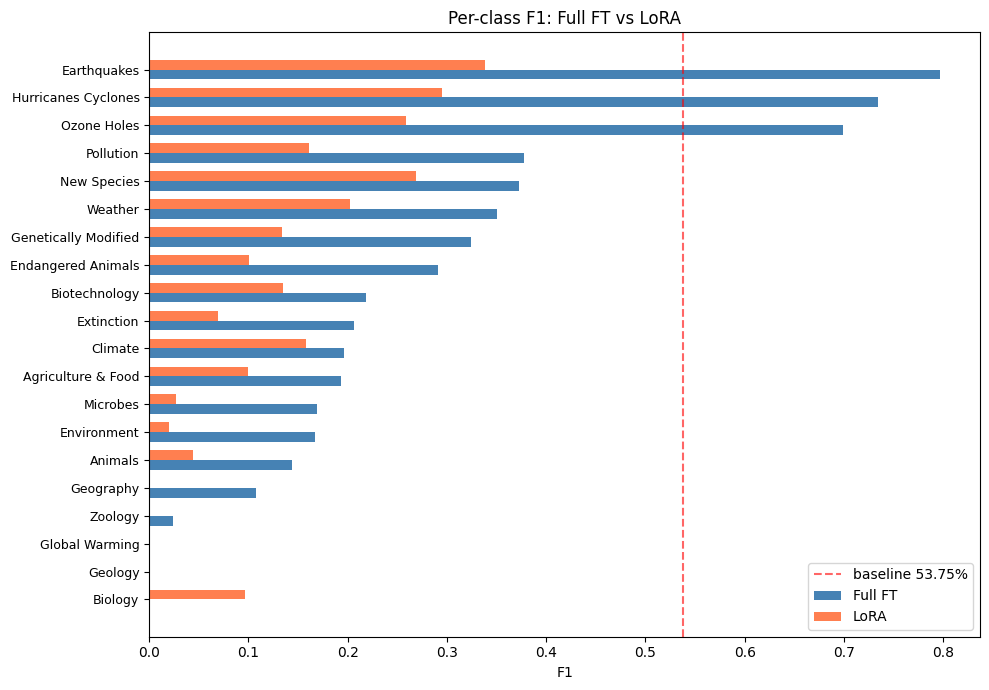

In [19]:
# per-class usporedba — merge
comparison = ft_per_class.merge(
    lora_per_class, on='category', suffixes=('_full_ft', '_lora')
).sort_values('f1_full_ft')

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(comparison))
width = 0.35
ax.barh(x - width/2, comparison['f1_full_ft'], width, label='Full FT', color='steelblue')
ax.barh(x + width/2, comparison['f1_lora'],    width, label='LoRA',    color='coral')
ax.set_yticks(x)
ax.set_yticklabels(comparison['category'], fontsize=9)
ax.axvline(0.5375, color='red', linestyle='--', alpha=0.6, label='baseline 53.75%')
ax.set_xlabel('F1')
ax.set_title('Per-class F1: Full FT vs LoRA')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# spremi usporedbu
comparison.to_csv(MODELS_DIR / 'comparison_per_class_f1.csv', index=False)
summary.to_csv(MODELS_DIR / 'comparison_summary.csv', index=False)
print('Usporedba spremljena.')

Usporedba spremljena.


In [34]:
import torch
import numpy as np
from collections import Counter

# 1. provjeri idu li class weights na GPU
print("Class weights device check:")
print(f"  weights: {class_weights[:5]}")
print()

# 2. provjeri distribuciju predikcija na test setu
print("Distribucija predikcija (Full FT):")
pred_counts = Counter(ft_pred_labels.tolist())
for label_id, count in sorted(pred_counts.items(), key=lambda x: -x[1]):
    print(f"  {id2label[label_id]:25s}: {count}")
print()

# 3. provjeri distribuciju true labela
print("Distribucija true labela (test):")
true_counts = Counter(ft_true_labels.tolist())
for label_id, count in sorted(true_counts.items(), key=lambda x: -x[1]):
    print(f"  {id2label[label_id]:25s}: {count}")

Class weights device check:
  weights: tensor([0.6842, 0.7616, 0.9301, 1.2536, 0.8255])

Distribucija predikcija (Full FT):
  Earthquakes              : 225
  Extinction               : 170
  Animals                  : 168
  Hurricanes Cyclones      : 152
  Genetically Modified     : 152
  Weather                  : 149
  Biotechnology            : 114
  Environment              : 113
  Ozone Holes              : 101
  Zoology                  : 85
  Pollution                : 74
  Biology                  : 70
  New Species              : 57
  Geography                : 57
  Microbes                 : 33
  Endangered Animals       : 9
  Climate                  : 2

Distribucija true labela (test):
  Earthquakes              : 148
  Pollution                : 142
  Genetically Modified     : 137
  Agriculture & Food       : 127
  Hurricanes Cyclones      : 126
  Animals                  : 114
  Weather                  : 108
  Climate                  : 105
  Endangered Animals       

In [35]:
# provjeri training history
ft_log = [x for x in ft_trainer.state.log_history if 'eval_macro_f1' in x]
for entry in ft_log:
    print(f"  epoch {entry['epoch']:.0f}:  val macro_f1 = {entry['eval_macro_f1']:.4f}  loss = {entry.get('eval_loss', 'n/a')}")

  epoch 1:  val macro_f1 = 0.0106  loss = 3.0129072666168213
  epoch 2:  val macro_f1 = 0.0064  loss = 2.98695707321167
  epoch 3:  val macro_f1 = 0.0465  loss = 2.8102941513061523
  epoch 4:  val macro_f1 = 0.0799  loss = 2.578950881958008
  epoch 5:  val macro_f1 = 0.1045  loss = 2.5205585956573486
  epoch 6:  val macro_f1 = 0.1197  loss = 2.4264109134674072
  epoch 7:  val macro_f1 = 0.1845  loss = 2.273303747177124
  epoch 8:  val macro_f1 = 0.1725  loss = 2.532482385635376
  epoch 9:  val macro_f1 = 0.2037  loss = 2.296677350997925
  epoch 10:  val macro_f1 = 0.1807  loss = 2.7487223148345947
  epoch 11:  val macro_f1 = 0.2138  loss = 2.4317569732666016
  epoch 12:  val macro_f1 = 0.2367  loss = 2.387291193008423
  epoch 13:  val macro_f1 = 0.2418  loss = 2.3275232315063477
  epoch 14:  val macro_f1 = 0.2389  loss = 2.4383463859558105
  epoch 15:  val macro_f1 = 0.2368  loss = 2.599867820739746
  epoch 16:  val macro_f1 = 0.2321  loss = 2.542959213256836
  epoch 16:  val macro_f1 